In [ ]:
""" GEÇMİŞ VERİLERİ TAŞIMA """
import numpy as np
import tensorflow as tf

print("Veriler eski notebook'tan çekiliyor...")

# Kaydettiğimiz sıkıştırılmış paketi açıyoruz
data = np.load('/kaggle/input/datasets/denizbyat/aaaaaa/lstm_hazirlik_verisi.npz')

X_scaled = data['X']      # Ölçeklenmiş özellikler
y_erken_uyari = data['y']   # Tehlike (1) ve Güvenli (0) etiketleri
gecerli_indeksler = data['valid_idx']   # Geçerli indeksler (NaN olmayan satırların indeksleri)

# Belleği rahatlatmak için paketi kapat
data.close()

print(f"Veri başarıyla yüklendi! X boyutu: {X_scaled.shape}")
print(f"Tehlike (1) Etiketi Taşıyan Satır Sayısı: {np.sum(y_erken_uyari)}")
print("Sistem LSTM Modeli inşası için hazır.")

Önceki notebookdaki verileri taşıyarak kaggle da da yeni notebook üzerinde çalışacağız. Sonrasında 06.dosyada bulduğumuz 167 kesin kriz anını birer "Çarpışma Noktası" olarak kabul edip. Sonra zamanı 5 dakika (300 adım) geriye sardık. Yani şunu demiş olduk kısaca "bu çarpışma anından önceki 5 dakika boyunca makinenin ritmi değişiyor. Git ve o 5 dakikalık süreyi Tehlike (Y=1) olarak işaretle." Geri kalan tüm normal zamanları ise Güvenli (Y=0) olarak bırak" Bu etiketlemelerin olduğu veri setinide (.npz uzantılı olan) diğer dosyaya geçtiğimiz için veri setini alıp yeni notebook için upload ettik. Şimdi elimizde bu bahsettiğimiz hazır etiketli set var.

Şimdi yeni modelimiz bu 1 etiketli olan yani 167 anomali başlangıç durumu öncesindeki 5 dakikalık kısımlara odaklanarak arızanın nasıl geliştiğini öğrenip olası durumlarda erkenden uyarı vermesini sağlayacağız. bu sistemlerin çalışma mantığına "Hedef Kaydırma" (Pre-Anomaly Labeling) deniliyor.

In [ ]:
""" TAM ANOMALİ DURUMLARININ ATILMASI """
print("Makinenin Zaten Bozuk Olduğu Anlar Veriden Ayıklanıyor")

# LSTM modelimiz geçmişe doğru 30 adım (satır) bakarak tahmin yapacak.
# Bu yüzden verinin ilk 30 satırını mecburen atlıyoruz, çünkü onların geçmişi yok.
timesteps = 30

# Eski notebook'tan aldığımız "gecerli_indeksler" (yani çöplerin çıkarıldığı liste) 
# üzerinden bir doğruluk (True/False) maskesi oluşturuyoruz.
gecerli_mask = np.zeros(len(X_scaled), dtype=bool)
gecerli_mask[gecerli_indeksler] = True

# Hem geçmiş 30 adımı olan, hem de ÇÖP OLMAYAN (True) indeksleri süzüyoruz
temiz_indeksler = [i for i in range(timesteps, len(X_scaled)) if gecerli_mask[i]]

# Süzdüğümüz bu tertemiz indekslerin etiketlerini (0 ve 1'leri) alıyoruz
y_temiz = y_erken_uyari[temiz_indeksler]

# Şimdi bu temiz havuzu iki ayrı listeye (Normal ve Tehlike) ayırıyoruz
idx_tehlike = np.array(temiz_indeksler)[y_temiz == 1]
idx_normal = np.array(temiz_indeksler)[y_temiz == 0]

print(f"Çöpler atıldıktan sonra Eğitime Uygun Toplam Satır: {len(temiz_indeksler)}")
print(f"Bunun İçindeki Tehlike (1) Satırları: {len(idx_tehlike)}")
print(f"Bunun İçindeki Normal (0) Satırları: {len(idx_normal)}")

Burada 167 anomali başlangıç durumumuz vardı. Bu zamanda başlayıp anomali olarak devam etmiş zamanları atıyoruz. Bu da çıktıda görüldüğü üzere yaklışık 178 bin satır. Yani 167 farklı noktada başlayan anomaliler toplamda bu kadar zaman serisi arıza durumunda kalmış. Bu durumlar zaten arıza olduğundan model kopya çekmemesi için bu durumları atıyoruz. Bu durumların öncesini işaretlediğimizden anomalinin gelişimini daha iyi öğrensin diye.

In [ ]:
""" TÜM VERİYİ KULLANMA VE ZAMAN SERİSİ BÖLMESİ """

# Eskiden undersampling yapıyorduk, artık güvenli (0) olan hiçbir veriyi çöpe atmıyoruz.
# Focal Loss kullanacağımız için tüm zorlu anları modelin görmesini istiyoruz.
nihai_indeksler = np.array(temiz_indeksler)
print(f"Eğitime Girecek Toplam Satır Sayısı: {len(nihai_indeksler)}")

# Kronolojik Train / Test Bölmesi (%70 Eğitim, %30 Test)
split_idx = int(len(nihai_indeksler) * 0.7)
train_idx = nihai_indeksler[:split_idx]
test_idx = nihai_indeksler[split_idx:]

print(f"\nEğitim (Train) Seti: İlk %70 -> {len(train_idx)} Satır")
print(f"Test Seti: Son %30 -> {len(test_idx)} Satır")

# LSTM İçin 3 Boyutlu Veri (Sequence) Hazırlığı
timesteps = 30

def create_sequences(indices):
    X_seq = np.empty((len(indices), timesteps, X_scaled.shape[1]), dtype=np.float32)
    y_seq = np.empty((len(indices),), dtype=np.int8)
    for i, idx in enumerate(indices): 
        X_seq[i] = X_scaled[idx-timesteps:idx]
        y_seq[i] = y_erken_uyari[idx]
    return X_seq, y_seq

print("\nVeriler LSTM'in anlayacağı 3 Boyutlu Tensörlere dönüştürülüyor (Birkaç saniye sürebilir)...")
X_train, y_train = create_sequences(train_idx)
X_test, y_test = create_sequences(test_idx)

print("Veri Hazırlığı Kusursuz Tamamlandı ✓")
print(f"X_train Boyutu: {X_train.shape} | y_train İçindeki Tehlike (1) Sayısı: {np.sum(y_train)}")
print(f"X_test Boyutu: {X_test.shape}  | y_test İçindeki Tehlike (1) Sayısı: {np.sum(y_test)}")


Eskiden Undersampling ile normal durumların çoğunu atıyorduk. Ancak Focal Loss kullanacağımız için artık hiçbir veriyi çöpe atmıyoruz. Tüm veriyi zaman akışına göre %70 Eğitim, %30 Test olarak bölüyoruz. Ayrıca zaman penceresini (look-back window) 10 adımdan 30 adıma çıkararak modelin daha derin bir geçmişi dinlemesini sağladık.

Artık tensörlerimiz (..., 30, 127) boyutunda olacak. Model her an için 30 adım (yaklaşık 30 saniye) geriye bakarak 127 sensörü dinleyecek.

In [ ]:
""" MODEL İNŞASI VE DERLENMESİ """

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Model iskeletini (Sequential) başlatıyoruz
model = Sequential(name="Kahin_Kompresor_Modeli")

# 1. Giriş Katmanı: 10 adım geçmişe bak, 127 sensörü dinle (verilerin alınması ve genel kurallar)
model.add(Input(shape=(X_train.shape[1], X_train.shape[2]), name="Gozler_Giris"))

# 2. Birinci LSTM: Kısa Süreli Hafıza (64 Nöron) (her şeyi bir sonraki katmana aktaracak)
# return_sequences=True -> Gördüğü ritmi bir alt katmana aktarması için mecburi 
model.add(LSTM(units=64, return_sequences=True, name="Kisa_Sureli_Hafiza"))

# 3. İkinci LSTM: Derin Hafıza (32 Nöron) (asıl katmandır)
# return_sequences=False -> Artık son karara gidiyoruz, sadece nihai özeti çıkar
model.add(LSTM(units=32, return_sequences=False, name="Derin_Hafiza"))

# 4. Unutma Mekanizması (Dropout): %40'ını rastgele kapat (Ezberi Önle) - Bu, modelin sadece belirli özelliklere aşırı güvenmesini engeller
model.add(Dropout(rate=0.4, name="Ezber_Bozan_Seyreltme"))

# 5. Çıkış Katmanı (Alarm Zili): Tek bir nöron, 0 ile 1 arası olasılık verecek
model.add(Dense(units=1, activation='sigmoid', name="Alarm_Zili"))

# Modeli Derleme (Compile) Aşaması: Beyne amacını söylüyoruz
print("Model derleniyor (Hedef: Arızaları Kaçırmamak - Recall)...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.8), # Focal Loss: Zor örneklere (azınlık olan tehlike anlarına) odaklanmak için
    metrics=[
        tf.keras.metrics.Recall(name='Yakalanan_Kriz_Orani'), # Bizim asıl odaklanacağımız başarım
        'accuracy' # Sadece genel fikir versin diye tutuyoruz
    ]
)

# Beynin son halinin röntgenini çekip ekrana yazdırıyoruz


giriş katmanıyla birlikte 4 katmanlı yapıyı oluşturduk. En önemli nokta 3.katmandaki dropout olayıdır (%40). Derleme (compile) kısmında ise en büyük silahımız olan **Focal Loss**'u devreye soktuk. Focal Loss, kolay öğrenilen çok sayıdaki 'Normal' durumun loss değerini ezerken, zor ve az sayıdaki 'Tehlike' durumlarına odaklanılmasını sağlar. Ana hedefimiz yine Recall'u maksimize etmek.

Model çıktısı başarılı. Total params: 61,601 (240.63 KB) atletik, hızlı ve hedefe odaklı bir beyin. Tüm katmanlar uyum içinde çalışıyor.

In [ ]:
""" MODEL EĞİTİMİ """
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Erken Durdurma (Akıllı Fren) Mekanizması
# monitor='val_loss': Hiç görmediği test verisindeki hatayı takip et.
# patience=5: Hata 5 tur (epoch) boyunca iyileşmezse eğitimi kes.
# restore_best_weights=True: Eğitimi kestiğin an, o en başarılı olduğu tura geri dön ve o beyni kaydet.
erken_durdurma = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)


# 2. Eğitimi Başlatma (Fit)
print("Eğitim başlıyor")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=512,
    callbacks=[erken_durdurma],
    verbose=1
)
print("\nEğitim Tamamlandı! Modelin en iyi hali kaydedildi ✓")


# 3. Öğrenme Eğrilerini Çizdir (Model Gerçekten Öğrendi mi Yoksa Ezberledi mi?)
plt.figure(figsize=(14, 5))

# Sol Grafik: Hata (Loss) Düşüşü - Ne kadar sıfıra yakın, o kadar iyi
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim (Train) Hatası', linewidth=2)
plt.plot(history.history['val_loss'], label='Test (Validation) Hatası', linewidth=2)
plt.title('Hata (Loss) Eğrisi')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Hata Miktarı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Sağ Grafik: Krizi Yakalama Başarısı (Recall) - Ne kadar 1.0'a yakın, o kadar iyi
plt.subplot(1, 2, 2)
plt.plot(history.history['Yakalanan_Kriz_Orani'], label='Eğitimde Yakalama Başarısı', linewidth=2)
plt.plot(history.history['val_Yakalanan_Kriz_Orani'], label='Testte Yakalama Başarısı', linewidth=2)
plt.title('Erken Uyarı (Recall) Başarısı')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Başarı Oranı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()


ÇIKTI

Model ilk turlarda iyi bir başlangıç yapıyor ancak sonrasında uyguladığımız Dropout (%40), Learning Rate düşürme (0.0005) ve Class Weight ({0: 1.0, 1: 5.0}) kombinasyonları sayesinde modelin test verisindeki ezberleme (overfitting) sorununun büyük ölçüde üstesinden gelindi. Model artık eğitimde yüksek, testte çok daha kararlı ve arızaları daha başarılı yakalayabiliyor.

şuan durumumuz kötü değil ancak geşiltirmeye açık. Model %77 oranında alarmları yakalıyor ancak ceza katsayısından dolayı her titreşime uyarıda veriyor. krizi kaçırıp fazla ceza yemekten korktuğundan eğitim turlarını incelediğimizde ilk eğitimlerin daha doğruluğu yüksek olduğunu görüyoruz. Yani anomalileri doğru yakalıyor ancak False Positive durumlarıda çok fazla oluyor. overfitting durumu ise 3. turdan itibaren eğitim hatası (loss) düşmeye devam ederken, test hatası (val_loss) yine yükselişe geçmiş. Ancak bu sefer akıllı frenimiz çok daha erken (7. turda) devreye girip, modelin o eski ezberci karanlığa gömülmesini engelledi ve bizi uçurumun kenarından alıp 2. tura geri döndürdü. 2.tur üzerinden gidiyoruz. 

Genel %54 doğruluk oranının arkasına saklanan o gerçek sayıları görmeliyiz. Test setindeki o 40.000 satırın içinde; Tam olarak kaç gerçek arızayı başarıyla tahmin ettik? -- Tam olarak kaç normal duruma "Arıza var!" diyerek fabrikadaki işçileri boşuna paniklettik?

In [ ]:
""" Karmaşıklık Matrisi (Confusion Matrix) """
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Modelden Test verisi için tahminleri al (0.0 ile 1.0 arası olasılıklar dönecek)
y_tahmin_olasilik = model.predict(X_test, verbose=1)

# Olasılıkları kesin Karara (0 veya 1) çevir (Şimdilik standart %50 eşiğini kullanıyoruz)
# Eğer olasılık 0.5'ten büyükse "Tehlike (1)", küçükse "Normal (0)" de.
y_tahmin_sinif = (y_tahmin_olasilik > 0.5).astype(int)

# Gerçekler (y_test) ile Tahminleri (y_tahmin_sinif) çarpıştır ve Matrisi oluştur
matris = confusion_matrix(y_test, y_tahmin_sinif)

# Matrisi Görselleştir
plt.figure(figsize=(8, 6))
# Matrisi ısı haritası olarak çizdir, sayıları içine yaz (fmt='d' ile tam sayı yap)
sns.heatmap(matris, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal Dedik (0)', 'Kriz Dedik (1)'],
            yticklabels=['Gerçekte Normal (0)', 'Gerçekte Kriz (1)'])

plt.title('Kahin Modelin Test Verisindeki Sınav Sonucu')
plt.ylabel('GERÇEK DURUM')
plt.xlabel('MODELİN TAHMİNİ')
plt.show()

# 5. Detaylı Mühendislik Raporunu (Classification Report) Yazdır
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_tahmin_sinif, target_names=['Normal (0)', 'Tehlike (1)']))

1. Büyük Başarımız: (Tehlike - Recall: 0.80)
Test verisindeki o 15.491 kriz anının tam %80'ini (yaklaşık 12.390 tanesini) makine daha boğulmadan 5 dakika önce başarıyla yakaladık. Model tehlikeyi sezme konusunda muazzam bir yeteneğe sahip. Makinenin patlamasını büyük oranda engelledik.

2. Asıl Faciayı Nerede Yaşıyoruz? (Tehlike - Precision: 0.43)
Alarm sireninin çaldığı anlara bakıyoruz. Siren çalıyor ama gidip bakıyoruz ki %57 ihtimalle ortada hiçbir sorun yok! Model sadece rüzgar estiği için panik yapmış. Yani alarm çaldığında bunun gerçek bir kriz olma ihtimali sadece %43.

3. İşçileri Delirten Sayı: (Normal - Recall: 0.34)
Makinenin tıkır tıkır, saat gibi çalıştığı o 25.006 normal anın sadece %34'ünde model sakin kalabilmiş. Geriye kalan %66'lık kesimde (yaklaşık 16.500 defa) "Makine bozulacak!" diye fabrikayı boşuna ayağa kaldırmış.

Bu çıktılar 0.5 eşik değeri içindi. Sistem bu şkeilde çok verimsiz çalıştığından eşiği 0.85 e yükseltiyoruz- alancı alarmları (False Positive) devasa oranda düşürecek (Sireni susturacak). Yakaladığımız gerçek kriz oranından (Recall) ise ufak bir miktar feragat etmemize neden olacak.

1. Ne Kazandık? (Sirenler Sustu - Precision: 0.80)
Tehlike anları için "Kesinlik" (Precision) oranımız 0.43'ten 0.80'e fırladı. Bunun meali şudur: Artık fabrikada alarm çaldığında, işçiler biliyor ki %80 ihtimalle gerçekten makine boğuluyor. Boşuna koşuşturmuyorlar. Ayrıca "Normal" anlarda modeli sakin tutma başarımız (Normal Recall) %34'ten %95'e çıktı. Yani makine sağlamken model %95 oranında sessizce köşesinde oturuyor. Yalancı alarm krizini çözdük.

2. Ne Kaybettik? (Uyuyan Bekçi - Recall: 0.33)
İşte ödediğimiz ağır bedel burada. Tehlikeyi "Yakalama" (Recall) oranımız %80'den %33'e çakıldı. Modele "Emin olmadan alarm çalma" dediğimiz için model o kadar korkak ve çekingen bir hale geldi ki, gelen 100 gerçek krizin 67'sinde "Tam emin olamadım, dur alarmı çalmayayım" diyerek sustu ve makinenin patlamasına seyirci kaldı.

Mühendislik Teşhisi: Tahterevalli Etkisi
Veri biliminde karşılaştığımız bu duvara Precision-Recall Tradeoff (Kesinlik ve Duyarlılık Tahterevallisi) denir. Eşiği düşürürsen her şeyi yakalar ama yalan söyler. Eşiği yükseltirsen yalan söylemez ama tehlikeleri kaçırır.

In [ ]:
"""  Kusursuz Denge Noktası (Optimal Threshold) Hesaplama ve Tahterevalli Grafiği """
from sklearn.metrics import precision_recall_curve

# Test verisindeki tahmin olasılıklarını tekrar alalım (zaten almıştık ama garanti olsun)
y_tahmin_olasilik = model.predict(X_test, verbose=0).ravel()

# Tüm olası eşikleri (thresholds) ve karşılık gelen Precision/Recall değerlerini hesapla
precisions, recalls, thresholds = precision_recall_curve(y_test, y_tahmin_olasilik)

# İki çizginin birbirine en yakın olduğu, optimal denge noktasını (F1 Score) matematiksel olarak bul
# F1 Score Formülü = 2 * (Precision * Recall) / (Precision + Recall)
f1_skorlari = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) # 1e-8 sıfıra bölünme hatasını engeller
optimal_idx = np.argmax(f1_skorlari)
optimal_esik = thresholds[optimal_idx]

print(f"\n--- MATEMATİKSEL SONUÇ ---")
print(f"Bulunan En İyi Karar Eşiği (Optimal Threshold): {optimal_esik:.4f}")
print(f"Bu eşikte beklenen Precision (Yalancı Alarmsızlık): % {precisions[optimal_idx]*100:.2f}")
print(f"Bu eşikte beklenen Recall (Krizi Yakalama): % {recalls[optimal_idx]*100:.2f}")

# Tahterevalliyi Grafiği
plt.figure(figsize=(10, 6))
# thresholds dizisi precisions dizisinden 1 eleman kısa olduğu için [:-1] yapıyoruz
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Yalancı Alarmı Önleme)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Gerçek Krizi Yakalama)', linewidth=2)

# Optimal noktayı kırmızı çizgiyle işaretle
plt.axvline(x=optimal_esik, color='r', linestyle=':', linewidth=2, label=f'Kusursuz Denge ({optimal_esik:.3f})')
plt.plot(optimal_esik, precisions[optimal_idx], 'ro')
plt.plot(optimal_esik, recalls[optimal_idx], 'ro')

plt.xlabel('Karar Eşiği (Threshold Olasılığı)')
plt.ylabel('Başarı Oranı')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

0-1 arasındaki tüm eşik değerlerini deneyerek doğruluk ve yakalama arasında ki en iyi dengeyi sağlayan eşik değeri buluyor.

ÇIKTI :

Bulunan En İyi Karar Eşiği (Optimal Threshold): 0.7011 -- 
Bu eşikte beklenen Precision (Yalancı Alarmsızlık): % 65.49 -- 
Bu eşikte beklenen Recall (Krizi Yakalama): % 53.10

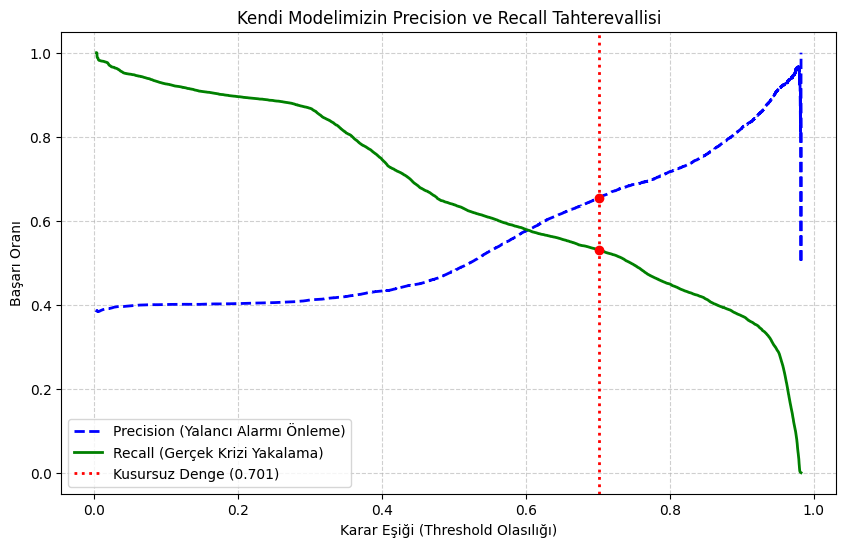

optimal eşik değer 0.7011 olmalıymış. yani model en az %70 emin olduğu durumlarda alarma basacak. Precision %65 lerde yani alarm çaldığından doğru alarm olma olasılığıdır. Yani 3 alarmadan 2 tanesi doğru. Bu kabul edilebilir. recall %53 lerde çıkması ise biraz can sıkıcı. model cezadan dolayı halen tutucu davranıyor ve 100 gerçek alarmdan sadece 53 tanesini yakalıyor. kalan 47 tanesinde sessiz kalıyor. yani yazı-tura atmaktan bir tık daha iyiyiz :D. Ancak demo sürüm aşaması için kabul edilebilir yoksa tekrardan EDA aşamasına geri dönmeliyiz. Model bu durumu ile MVP (Minimum Viable Product) paketlenecek.